# High-Performance Learning Dynamics in General-Sum Games
This notebook demonstrates how to run learning dynamics (OMWU, ExtraGradient, MWU, GDA) with high-performance PyTorch GPU acceleration, multi-step unrolling (`steps_per_call`), incremental chunked statistics loading (`load_experiment_stats`), and parallel multi-game ensemble evaluation (`BatchNPlayerGame`).

## 1. Single Experiment with Multi-Step Unrolling (`steps_per_call=500`)
Unrolling $K=500$ steps in PyTorch GPU execution blocks eliminates Python loop overhead and achieves maximum step throughput.

In [1]:
import sys; sys.path.append('..')
import torch
import matplotlib.pyplot as plt
from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig
from src.engine.runner import ExperimentRunner
from src.engine.statistics import load_experiment_stats

# 1. Configure OMWU on Matching Pennies starting OFF-equilibrium ([0.8, 0.2] & [0.3, 0.7])
config = ExperimentConfig(
    name="notebook_omwu_demo",
    game=GameConfig(generator="matching_pennies", utility_range=(-1.0, 1.0), payoffs=[[[1, 0.5], [0.5, 1]], [[1, -1], [0.5, 1]]]),
    dynamic=DynamicConfig(
        algorithm="mirror_prox",
        strict_theory_eta=True,
        initial_strategy_type="custom",
        custom_initial_strategies=[[0.9, 0.1], [0.2, 0.8]]
    ),
    execution=ExecutionConfig(total_steps=20000, device="auto", steps_per_call=500, seed=42, compile=True)
)

# 2. Run simulation
runner = ExperimentRunner(config=config)
summary = runner.run()

[08/01/26 21:30:56] INFO     Enabling PyTorch JIT compilation via torch.compile(backend='cudagraphs')...

[08/01/26 21:30:57] INFO     Starting simulation 'notebook_omwu_demo' [Session:                                    
                             cf3d38a8-67f4-479e-ae04-3e014fdbf3b8] on device 'cuda' for T=20000 steps.

Output()

[08/01/26 21:31:08] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.003927. Stats session ID        
                             'cf3d38a8-67f4-479e-ae04-3e014fdbf3b8' in 'outputs'

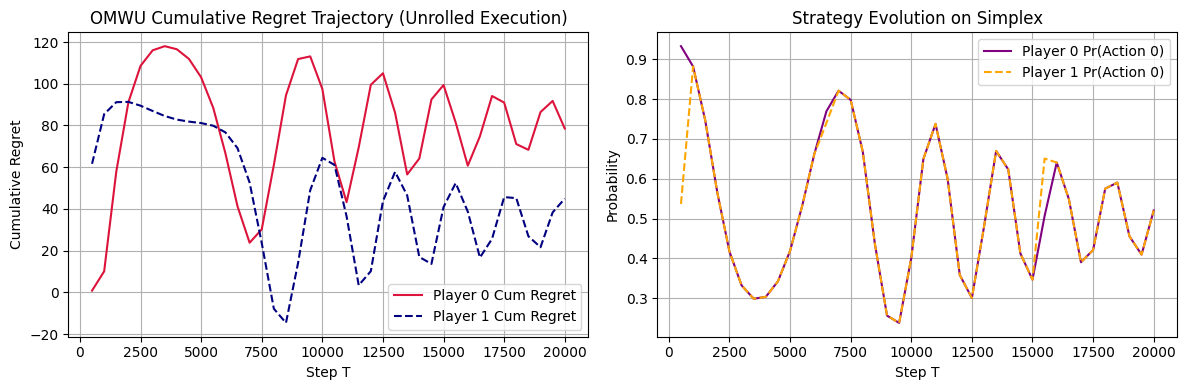

In [2]:
# 3. Load & Plot Statistics using load_experiment_stats (seamlessly concatenates chunked stats files)
stats_data = load_experiment_stats(output_dir=summary["output_dir"], session_id=summary["session_id"])
steps = stats_data["steps"].numpy()
cum_regrets = stats_data["cum_regrets"].numpy()
strats = stats_data["strategies"]  # List of 2D tensors [T x A_i] per player

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regret Curve
axes[0].plot(steps, cum_regrets[:, 0], label="Player 0 Cum Regret", color="crimson")
axes[0].plot(steps, cum_regrets[:, 1], label="Player 1 Cum Regret", color="navy", linestyle="--")
axes[0].set_xlabel("Step T")
axes[0].set_ylabel("Cumulative Regret")
axes[0].set_title("OMWU Cumulative Regret Trajectory (Unrolled Execution)")
axes[0].grid(True)
axes[0].legend()

# Strategy Trajectory for Player 0 & 1 (Probability of Action 0)
axes[1].plot(steps, strats[0][:, 0].numpy(), color="purple", label="Player 0 Pr(Action 0)")
axes[1].plot(steps, strats[1][:, 0].numpy(), color="orange", label="Player 1 Pr(Action 0)", linestyle="--")
axes[1].set_xlabel("Step T")
axes[1].set_ylabel("Probability")
axes[1].set_title("Strategy Evolution on Simplex")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
runner.game.get_payoff_tensors()

[tensor([[ 1., -1.],
         [-1.,  1.]], device='cuda:0'),
 tensor([[-1.,  1.],
         [ 1., -1.]], device='cuda:0')]

## 2. Multi-Algorithm Benchmark (OMWU vs ExtraGradient vs MWU vs GDA)
Compare throughput and regret convergence across all 4 learning dynamics algorithms.

In [4]:
import time

algorithms = ["omwu", "mwu", "mirror_prox"]
results = {}

for algo in algorithms:
    exp = ExperimentConfig(
        name=f"benchmark_{algo}",
        game=GameConfig(generator="matching_pennies"),
        dynamic=DynamicConfig(algorithm=algo, strict_theory_eta=False),
        execution=ExecutionConfig(total_steps=20000, device="auto", steps_per_call=500, seed=42)
    )
    t0 = time.time()
    run_summary = ExperimentRunner(config=exp).run()
    elapsed = time.time() - t0
    sps = 20000 / elapsed
    results[algo] = sps
    print(f"Algorithm {algo.upper():16s}: {sps:6.1f} steps/second")

                    INFO     Starting simulation 'benchmark_omwu' [Session: d8ff7f8c-383f-4c89-b565-bd156e130d2a]  
                             on device 'cuda' for T=20000 steps.

Output()

[08/01/26 21:31:14] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000000. Stats session ID        
                             'd8ff7f8c-383f-4c89-b565-bd156e130d2a' in 'outputs'

Algorithm OMWU            : 3854.6 steps/second


                    INFO     Starting simulation 'benchmark_mwu' [Session: bf43c4e8-aca2-4c76-99cf-3d561aa13bc4] on
                             device 'cuda' for T=20000 steps.

...

Algorithm MWU             : 4658.9 steps/second


                    INFO     Starting simulation 'benchmark_mirror_prox' [Session:                                 
                             3102c3da-2b11-477e-ba83-badce82faeb3] on device 'cuda' for T=20000 steps.

Output()

[08/01/26 21:31:25] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000000. Stats session ID        
                             '3102c3da-2b11-477e-ba83-badce82faeb3' in 'outputs'

Algorithm MIRROR_PROX     : 2764.2 steps/second


## 3. Parallel Multi-Game Ensemble Execution (`BatchNPlayerGame`)
Simulate $B=100$ random game instances in parallel on GPU simultaneously using batched tensor contractions.

In [5]:
from src.games.nplayer_game import BatchNPlayerGame
from src.dynamics.omwu import OptimisticMWU

B = 100  # 100 parallel game instances
N = 3    # 3-player games
actions = [3, 3, 3]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generate 100 random game payoff matrices on GPU
batch_payoffs = [
    torch.randn(B, *actions, device=device, dtype=torch.float32)
    for _ in range(N)
]
batch_game = BatchNPlayerGame(batch_payoffs=batch_payoffs, device=device)

# Initialize OMWU dynamics for all 100 games simultaneously
dynamic = OptimisticMWU(action_sizes=actions, T=10000, strict_theory_eta=False, device=device)
dynamic.reset()

print(f"Successfully initialized ensemble of {B} parallel 3-player games on device '{device}'!")

Successfully initialized ensemble of 100 parallel 3-player games on device 'cuda'!
